In [1]:
import pandas as pd
from autorank import autorank, plot_stats, create_report, latex_table

In [2]:
df = pd.read_csv("results.csv")
df.sample(5)

,id_alg,param_1,param_2,param_3,id_dataset,param_4,mean_ind,std_ind,fold_0,fold_1,fold_2,fold_3,fold_4,fold_5,fold_6,fold_7,fold_8,fold_9
374,3,-1,0,10,7,1,0.728333,0.083100,0.841667,0.708333,0.566667,0.841667,0.691667,0.691667,0.741667,0.816667,0.650000,0.733333
483,14,-1,-,10,1,1,0.920000,0.060000,1.000000,0.900000,0.900000,0.900000,0.900000,0.900000,1.000000,1.000000,0.800000,0.900000
521,14,-1,-,10,5,60,0.854601,0.064015,0.913043,0.788043,0.958333,0.875000,0.831522,0.916084,0.839161,0.861888,0.723776,0.839161
310,11,5,1,5,6,60,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,3,-1,0,10,1,60,0.930000,0.064031,0.900000,0.900000,0.900000,1.000000,1.000000,0.800000,1.000000,0.900000,1.000000,0.900000


In [3]:
dataset_ids = sorted(df['id_dataset'].unique())
algorithm_ids = df['id_alg'].unique()
print("Datasets:", dataset_ids)
print("Algorithms:", algorithm_ids)
fold_columns = list(map(lambda x: f'fold_{x}', range(0, 10)))

Datasets: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Algorithms: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [4]:

algorithms = {
    alg_id: df[df['id_alg'] == alg_id][fold_columns] 
    for alg_id in sorted(df['id_alg'].unique())
}

print(algorithms[1].head(1))

   fold_0  fold_1  fold_2  fold_3  fold_4  fold_5  fold_6  fold_7  fold_8  \
0     0.9     0.9     0.9     1.0     1.0     0.8     1.0     0.9     1.0   

   fold_9  
0     0.8  


Fail to reject null hypothesis that data is normal for column 1 (p=0.005032>=0.003571)
Fail to reject null hypothesis that data is normal for column 2 (p=0.009421>=0.003571)
Rejecting null hypothesis that data is normal for column 3 (p=0.002375<0.003571)
Fail to reject null hypothesis that data is normal for column 4 (p=0.008135>=0.003571)
Rejecting null hypothesis that data is normal for column 5 (p=0.000361<0.003571)
Rejecting null hypothesis that data is normal for column 6 (p=0.000843<0.003571)
Fail to reject null hypothesis that data is normal for column 7 (p=0.014941>=0.003571)
Rejecting null hypothesis that data is normal for column 8 (p=0.001126<0.003571)
Rejecting null hypothesis that data is normal for column 9 (p=0.001083<0.003571)
Rejecting null hypothesis that data is normal for column 10 (p=0.001629<0.003571)
Rejecting null hypothesis that data is normal for column 11 (p=0.001985<0.003571)
Rejecting null hypothesis that data is normal for column 12 (p=0.000893<0.003571)
F

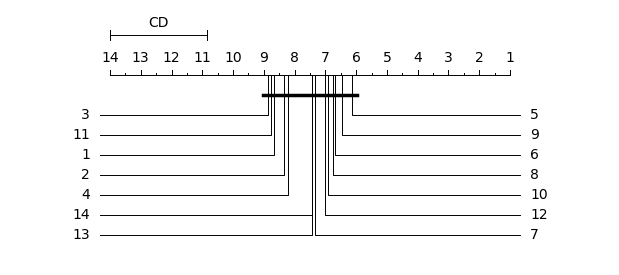

In [5]:
# Convert integer IDs to strings to satisfy autorank's report generator
first_fold = {str(alg_id): d['fold_0'].values for alg_id, d in algorithms.items()}
data = pd.DataFrame(first_fold)

# Now run autorank as before
reults = autorank(data, alpha=0.05, verbose=True)
plot_stats(reults)
print(create_report(reults))


In [ ]:
#!jupyter nbconvert --output 's03_notebook_Ciobanu_Sergiu_Tudor.html' --to html seminar_3.ipynb

[NbConvertApp] Converting notebook seminar_3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 306882 bytes to s03_notebook_Ciobanu_Sergiu_Tudor.html
